The source of this notebook is available at https://github.com/gphanikumar/tpnotes

# Channel flow with moving plane

The solution plotted in this notebook is for the problem of unidirectional steady state flow of an incompressible, Newtonian fluid between two planes where one plane at x=0 is stationary and the other plane at x=d is moving upwards at a velocity u0. Gravity is along the direction opposite to the flow. Pressure gradient term can be ignored. The problem is said to be 2D so that variation along z direction can be considered as not there. V(x) is to be determine and plotted. Look at the notes to see the derivation.

$$ V(x) = {\rho g \over 2 \mu} x (x-\delta) + {u_0 \over \delta} x $$

In [1]:
var('u0,d,mu,rho,x')

(u0, d, mu, rho, x)

In [2]:
g=9.81

In [3]:
rho=1000

In [4]:
mu=0.1

In [5]:
V=((rho*g)/(2*mu))*x*(x-d) + (u0/d)*x

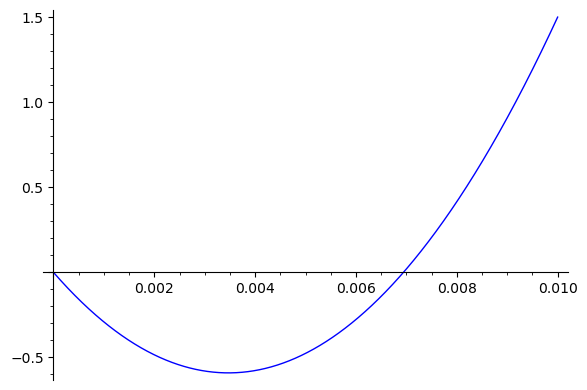

In [6]:
p1=plot(V.subs(d=0.01,u0=1.5),(x,0,0.01))
p1.show()

## Critical velocity to avoid downward flow

If the right side plane is moving up fast enough, there is no downward flow in the channel.

In [7]:
ucrit = d*d*rho*g/(2*mu)

In [8]:
ucrit.subs(d=0.01)

4.90500000000000

As the velocity of the right side plane increases, the velocity profile gets lifted up. When the velocity of the right side plane is above a critical velocity, downward flow is avoided.

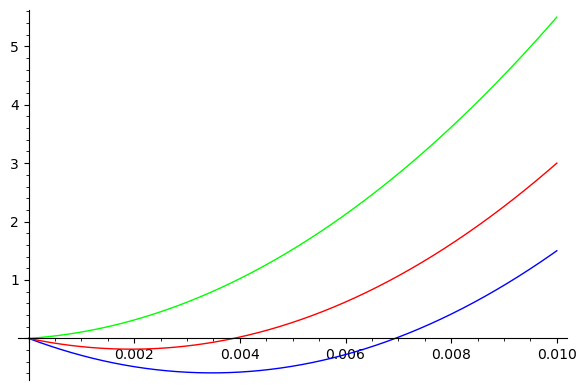

In [9]:
p2a=plot(V.subs(d=0.01,u0=3.0),(x,0,0.01), rgbcolor=(1,0,0))
p2b=plot(V.subs(d=0.01,u0=5.5),(x,0,0.01), rgbcolor=(0,1,0))
(p1+p2a+p2b).show()

## Maximum downward velocity

We can locate the maximum velocity by solving for the xmax when the slope of the velocity is zero.

In [10]:
xmax = solve(V.diff(x)==0,x)[0]

In [11]:
soln = xmax.subs(rho=1000,mu=0.1,d=0.01,u0=1.5)
soln

x == 0.00347094801223242

In [12]:
x0 = x.subs(soln)
V0 = V.subs(x=x0, rho=1000, mu=0.1, d=0.01, u0=1.5)

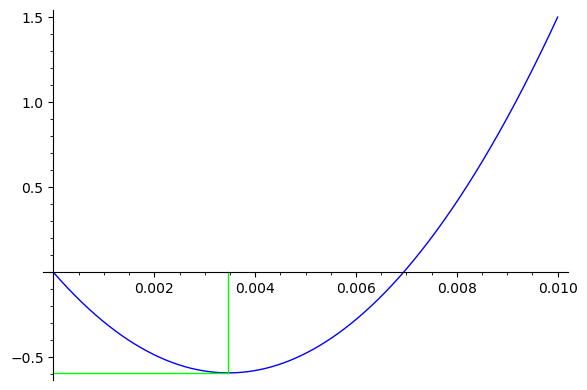

In [13]:
L1 = [[x0, 0],[x0,V0]]
l1 = line(L1, rgbcolor=(0,1,0))
L2 = [[0, V0],[x0,V0]]
l2 = line(L2, rgbcolor=(0,1,0))
g = p1 + l1 + l2
g.show()

## Location of velocity reversal

The location when the velocity flips over from downward to upwards can be solved for by setting V=0.

In [14]:
eqn1 = V.subs(rho=1000, mu=0.1, d=0.01, u0=1.5)==0
sol1 = solve(eqn1,x)
x1 = sol1[0].rhs()

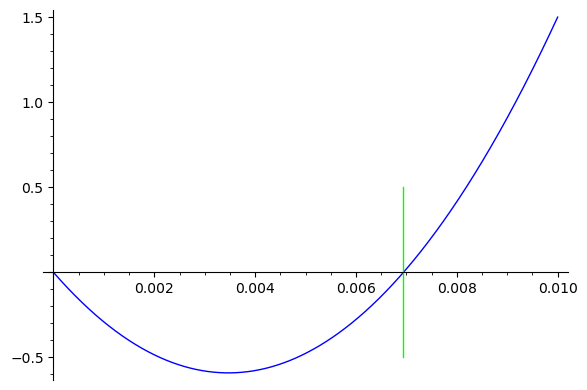

In [15]:
L3 = [[x1, -0.5],[x1,0.5]]
l3 = line(L3, rgbcolor=(0,1,0))
g = p1 + l3
g.show()

## Zero net flow across a y-plane

The value of u0 for zero netflow across any y-plane can be obtained by integrating the velocity profile across the domain and setting it to zero.

In [16]:
flowrate = V.subs(rho=1000, mu=0.1, d=0.01).integrate(x)
flowrate

50.0*u0*x^2 + 16350.0*x^3 - 245.25*x^2

In [17]:
eqn2 = flowrate == 0
sol2 = solve(eqn2.subs(x=0.01),u0)
u1 = sol2[0].rhs()
u1.n()

1.63500000000000

The flow rate as function of distance along channel width is as follows. The netflow rate reaches zero at the right side plane.

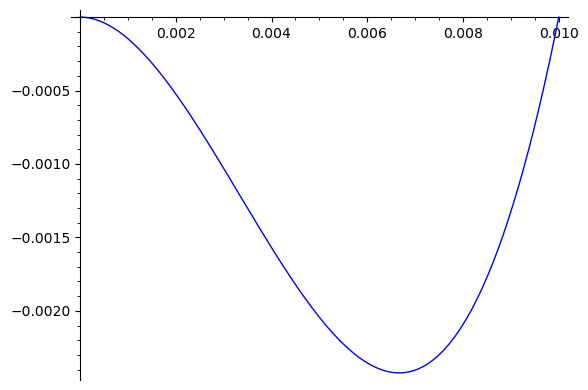

In [18]:
p3a = plot(flowrate.subs(u0=u1),(x,0,0.010))
p3a.show()

The velocity profile for the situation of zero netflow is as follows.

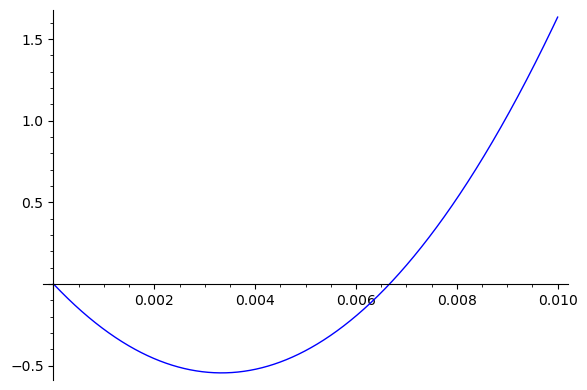

In [19]:
p3b = plot(V.subs(rho=1000, mu=0.1, d=0.01, u0=u1),(x,0,0.01))
p3b.show()

## Shear stress profile

The shear stress in the liquid as a function of distance in the channel is given by the following equation.

$$ \tau = \mu {\partial V \over \partial x} $$

Note that the location of zero shear stress where the velocity profile has zero slope. 

In [20]:
shearstress = mu * V.subs(rho=1000, mu=0.1, d=0.01, u0=u1).diff(x)

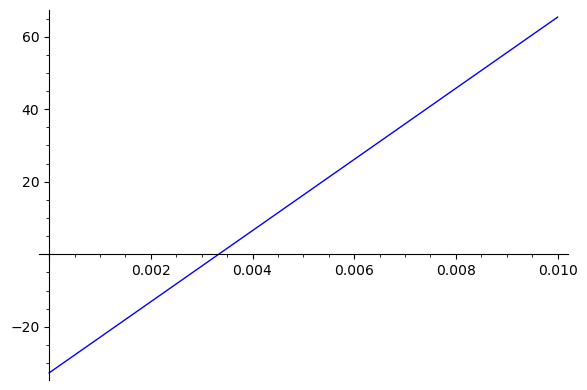

In [21]:
plot(shearstress,(x,0,0.01))